# HAWQ-V3 Implementation — RQNKUP

**Paper:** HAWQ-V3: Dyadic Neural Network Quantization (Yao, Dong, Zheng, Gholami et al., ICML 2021)

**How to use this notebook**
1. In **0. Setup → CONFIG**, set `MODEL_NAME` to `"resnet18"`, `"resnet50"`, or `"inceptionv3"`.
2. **Runtime → Restart session**, then **Runtime → Run all**.
3. Every model-specific value (input size, batch sizes, paper reference numbers, file names) comes from the CONFIG cell. Nothing else needs editing.

**Important scope note.** This is a *post-training*, *simulated* (fake-quantization) reproduction of HAWQ-V3's pipeline: Hessian-based sensitivity → ILP bit allocation → evaluation. There is **no retraining**. The paper's accuracy numbers come from quantization-aware fine-tuning and integer-only TVM kernels, so accuracies here (especially at INT4) are expected to be much lower. What this notebook compares fairly is how well each **sensitivity metric** chooses which layers to keep at 8-bit, under identical budgets.

# 0. Setup

In [ ]:
# Install dependencies and clone the official HAWQ repo (read-only reference)
!pip install -q pytorchcv pulp datasets
![ -d HAWQ ] || git clone -q https://github.com/Zhen-Dong/HAWQ.git

In [ ]:
# Mount Google Drive to save data and results
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# CONFIG -- the ONLY cell you edit to switch models.
# ============================================================
MODEL_NAME = "resnet50"   # "resnet18" | "resnet50" | "inceptionv3"

MODEL_CONFIGS = {
    "resnet18": dict(
        input_size=224, resize_size=256,          # standard ImageNet eval: resize 256 -> crop 224
        hessian_batch=64, hutchinson_iters=20,    # double-backward batch size & Hutchinson iterations
        eig_subset=128, eig_batch=64, eig_iters=8,
        paper_fp32_acc=71.47, paper_fp32_bops_g=1858, paper_fp32_size_mb=44.6,
    ),
    "resnet50": dict(
        input_size=224, resize_size=256,
        hessian_batch=16, hutchinson_iters=20,    # smaller batch: batch 128 ran out of GPU memory
        eig_subset=128, eig_batch=16, eig_iters=8,
        paper_fp32_acc=77.72, paper_fp32_bops_g=3951, paper_fp32_size_mb=97.8,
    ),
    "inceptionv3": dict(
        input_size=299, resize_size=342,          # 299 / 0.875 = 342 (same 87.5% center-crop ratio)
        hessian_batch=8, hutchinson_iters=20,
        eig_subset=64, eig_batch=8, eig_iters=8,  # ~95 layers, so the per-layer eigenvalue loop is cut down
        paper_fp32_acc=78.88, paper_fp32_bops_g=5850, paper_fp32_size_mb=90.9,
    ),
}
CFG = MODEL_CONFIGS[MODEL_NAME]

RUN_TOP_EIGENVALUE = True       # slowest step (HAWQ-V1 baseline); set False to skip it
RECOMPUTE_SENSITIVITY = False   # True = ignore cached Hessian results in Drive and recompute

In [ ]:
# Imports & constants (nothing to edit here -- model-specific values come from CFG)
import os, glob, json, random, itertools, importlib.util
from contextlib import contextmanager

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from torch.utils.data import TensorDataset, DataLoader

from google.colab import userdata
from datasets import load_dataset
from pytorchcv.model_provider import get_model as ptcv_get_model
import pulp

HF_TOKEN = userdata.get("HF_TOKEN")

# ---- reproducibility ----
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE} | model: {MODEL_NAME} | input size: {CFG['input_size']}")

# ---- paths (Google Drive) ----
PROJECT_DIR  = "/content/drive/MyDrive/rqnkup"
DATA_DIR     = os.path.join(PROJECT_DIR, "hawqv3_data")
RESULTS_ROOT = os.path.join(PROJECT_DIR, "hawqv3", "results")
RESULTS_DIR  = os.path.join(RESULTS_ROOT, MODEL_NAME)     # one subfolder per model
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---- dataset split sizes (disjoint: eval / hessian / calibration) ----
N_EVAL    = 10_000   # accuracy measurement
N_HESSIAN = 512      # Hessian computations (HAWQ-V2: trace estimates converge beyond ~512 images)
N_CALIB   = 512      # activation range calibration
N_TOTAL   = N_EVAL + N_HESSIAN + N_CALIB

# one data file per input size: resnet18/resnet50 share the 224 file, inceptionv3 uses 299
DATA_FILE = os.path.join(DATA_DIR, f"imagenet_val_{CFG['input_size']}_n{N_TOTAL}.pt")
if not os.path.exists(DATA_FILE):   # reuse a copy saved elsewhere in the project folder, if any
    matches = glob.glob(os.path.join(PROJECT_DIR, "**", os.path.basename(DATA_FILE)), recursive=True)
    if matches:
        DATA_FILE = matches[0]
print("Data file:", DATA_FILE, "(found)" if os.path.exists(DATA_FILE) else "(will be created)")

# ---- preprocessing: standard ImageNet eval recipe, stored as uint8 ----
preprocess = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")),   # force 3 channels (some images are grayscale/CMYK)
    T.Resize(CFG["resize_size"]),               # shorter side -> resize_size, keeps proportions
    T.CenterCrop(CFG["input_size"]),            # center square of input_size x input_size
    T.PILToTensor(),                            # uint8 tensor (3, H, W)
])

# ---- normalization, applied on the GPU at batch time (NOT stored) ----
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

BIT_CHOICES = [4, 8]
EVAL_BATCH  = 128

def normalize_batch(uint8_batch):
    """uint8 (B, 3, H, W) on CPU -> normalized float32 on DEVICE."""
    x = uint8_batch.to(DEVICE).float() / 255.0
    return (x - IMAGENET_MEAN) / IMAGENET_STD

Device: cuda | model: resnet50 | input size: 224
Data file: /content/drive/MyDrive/rqnkup/hawqv3_data/imagenet_val_224_n11024.pt (found)


# 1. Dataset(s) used

**ImageNet (ILSVRC2012) validation set**, streamed from Hugging Face (`ILSVRC/imagenet-1k`). No training images are needed because nothing is retrained.

A shuffled subset of 11,024 images (fixed seed) is split into three **disjoint** groups so that evaluation, sensitivity computation, and calibration never see the same images:
- **10,000** images for Top-1 accuracy (±~0.9% at 95% confidence around 70% accuracy)
- **512** images for the Hessian computations
- **512** images for activation-range calibration

Images are preprocessed once (resize → center crop → `uint8`) and cached in Drive. ResNet-18/50 share the 224×224 file; Inception-V3 gets its own 299×299 file. The same seed selects the same images for both files.

In [ ]:
# Stream a shuffled ImageNet val subset and save it to Drive (skipped if the file already exists)
if os.path.exists(DATA_FILE):
    print("Subset already saved, skipping download:", DATA_FILE)
else:
    stream = load_dataset("ILSVRC/imagenet-1k", split="validation",
                          streaming=True, token=HF_TOKEN)
    stream = stream.shuffle(seed=SEED, buffer_size=10_000).take(N_TOTAL)

    S = CFG["input_size"]
    images = torch.empty((N_TOTAL, 3, S, S), dtype=torch.uint8)   # preallocated: no list + stack copy
    labels = torch.empty(N_TOTAL, dtype=torch.long)
    count = 0
    for i, ex in enumerate(tqdm(stream, total=N_TOTAL, desc=f"Streaming ImageNet val ({S}x{S})")):
        images[i] = preprocess(ex["image"])
        labels[i] = ex["label"]
        count += 1
    assert count == N_TOTAL, f"Only streamed {count} of {N_TOTAL} images"

    torch.save({"images": images, "labels": labels}, DATA_FILE)
    print(f"Saved {count} images to {DATA_FILE}")
    del images, labels   # free RAM before the load cell makes its own copy

Subset already saved, skipping download: /content/drive/MyDrive/rqnkup/hawqv3_data/imagenet_val_224_n11024.pt


In [ ]:
# Load the subset and split it into disjoint eval / hessian / calibration loaders
data = torch.load(DATA_FILE)
all_images, all_labels = data["images"], data["labels"]
del data
S = CFG["input_size"]
assert tuple(all_images.shape) == (N_TOTAL, 3, S, S), f"Unexpected data shape {tuple(all_images.shape)}"
assert all_images.dtype == torch.uint8
print("Loaded:", tuple(all_images.shape), all_images.dtype,
      "| unique classes:", all_labels.unique().numel())

i1, i2 = N_EVAL, N_EVAL + N_HESSIAN
eval_images,    eval_labels    = all_images[:i1],   all_labels[:i1]
hessian_images, hessian_labels = all_images[i1:i2], all_labels[i1:i2]
calib_images,   calib_labels   = all_images[i2:],   all_labels[i2:]

def make_loader(images, labels, batch_size):
    # num_workers=0: data is already in memory, and worker processes caused
    # noisy AssertionError spam on Colab's Python 3.13
    return DataLoader(TensorDataset(images, labels), batch_size=batch_size,
                      shuffle=False, num_workers=0)

eval_loader    = make_loader(eval_images, eval_labels, EVAL_BATCH)
calib_loader   = make_loader(calib_images, calib_labels, EVAL_BATCH)
hessian_loader = make_loader(hessian_images, hessian_labels, CFG["hessian_batch"])
eig_loader     = make_loader(hessian_images[:CFG["eig_subset"]],
                             hessian_labels[:CFG["eig_subset"]], CFG["eig_batch"])

print(f"eval: {len(eval_images)} imgs / {len(eval_loader)} batches | "
      f"hessian: {len(hessian_images)} / {len(hessian_loader)} | "
      f"eigen subset: {CFG['eig_subset']} / {len(eig_loader)} | "
      f"calib: {len(calib_images)} / {len(calib_loader)}")

Loaded: (11024, 3, 224, 224) torch.uint8 | unique classes: 1000
eval: 10000 imgs / 79 batches | hessian: 512 / 32 | eigen subset: 128 / 8 | calib: 512 / 4


README.md:   0%|          | 0.00/87.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

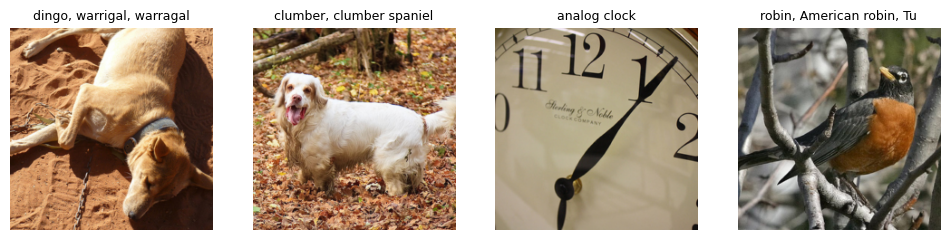

In [ ]:
# Sanity check: a few images with their class names
try:
    label_names = load_dataset("ILSVRC/imagenet-1k", split="validation",
                               streaming=True, token=HF_TOKEN).features["label"].int2str
except Exception as e:
    print("Could not load class names, showing label ids instead:", e)
    label_names = str

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, i in zip(axes, range(4)):
    ax.imshow(eval_images[i].permute(1, 2, 0).numpy())
    ax.set_title(label_names(int(eval_labels[i]))[:25], fontsize=9)
    ax.axis("off")
plt.show()

# 2. Model(s) used

Pretrained **ResNet-18**, **ResNet-50**, and **Inception-V3** from **PyTorchCV**, the library the paper used for its strong FP32 baselines (71.47%, 77.72%, 78.88%). The model is only evaluated, never trained.

This section also builds the **layer inventory**: every `Conv2d`/`Linear` layer in *execution order* (recorded with forward hooks, which is reliable even for Inception's parallel branches), with its weight count and MACs. Following the paper, the **first and last layers are always kept at 8-bit**. The printed totals are checked against the paper's FP32 size and BOPS.

In [ ]:
# Load the pretrained model in eval mode (BatchNorm uses running stats, dropout off)
model = ptcv_get_model(MODEL_NAME, pretrained=True).to(DEVICE)
model.eval()
print(f"Loaded {MODEL_NAME}: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters")

Loaded resnet50: 25.56M parameters


In [ ]:
# Top-1 accuracy on the eval split
@torch.no_grad()
def evaluate_top1(model, loader, desc="eval"):
    model.eval()
    correct, total = 0, 0
    for images, labels in tqdm(loader, desc=desc):
        preds = model(normalize_batch(images)).argmax(dim=1)
        correct += (preds == labels.to(DEVICE)).sum().item()
        total += labels.numel()
    return 100.0 * correct / total

fp32_acc = evaluate_top1(model, eval_loader, desc="FP32 baseline")
print(f"FP32 Top-1: {fp32_acc:.2f}%  (paper, full 50k val set: {CFG['paper_fp32_acc']:.2f}%)")
if abs(fp32_acc - CFG["paper_fp32_acc"]) > 2.0:
    print("WARNING: more than 2 points from the paper's baseline -- check preprocessing "
          "(resize/crop size, normalization) and label order before trusting anything below.")

FP32 baseline:   0%|          | 0/79 [00:00<?, ?it/s]

FP32 Top-1: 77.77%  (paper, full 50k val set: 77.72%)


In [ ]:
# Layer inventory in EXECUTION order: weight counts + MACs (from output shapes via forward hooks)
def build_layer_inventory(model, input_size):
    candidates = {name: m for name, m in model.named_modules()
                  if isinstance(m, (nn.Conv2d, nn.Linear))}
    order, macs, handles = [], {}, []

    def make_hook(name):
        def hook(mod, inputs, output):
            if name in macs:          # module called twice: count it once
                return
            if isinstance(mod, nn.Conv2d):
                k_h, k_w = mod.kernel_size
                macs[name] = (mod.out_channels * output.shape[-2] * output.shape[-1]
                              * (mod.in_channels // mod.groups) * k_h * k_w)
            else:
                macs[name] = mod.in_features * mod.out_features
            order.append(name)
        return hook

    for name, m in candidates.items():
        handles.append(m.register_forward_hook(make_hook(name)))
    with torch.no_grad():
        model(torch.zeros(1, 3, input_size, input_size, device=DEVICE))
    for h in handles:
        h.remove()

    inventory = {}
    for name in order:
        m = candidates[name]
        inventory[name] = {
            "module": m,
            "weight_numel": m.weight.numel(),
            "bias_numel": m.bias.numel() if m.bias is not None else 0,
            "macs": macs[name],
        }
    unused = [n for n in candidates if n not in macs]
    return inventory, unused

layer_inventory, unused_layers = build_layer_inventory(model, CFG["input_size"])
layer_names = list(layer_inventory.keys())
first_layer_name, last_layer_name = layer_names[0], layer_names[-1]
FIXED_8BIT = {first_layer_name, last_layer_name}

print(f"{len(layer_names)} quantizable layers (execution order)"
      + (f"; {len(unused_layers)} defined but never called (ignored)" if unused_layers else ""))
print("First layer (kept 8-bit):", first_layer_name, type(layer_inventory[first_layer_name]["module"]).__name__)
print("Last layer  (kept 8-bit):", last_layer_name, type(layer_inventory[last_layer_name]["module"]).__name__)
if not isinstance(layer_inventory[last_layer_name]["module"], nn.Linear):
    print("WARNING: the last executed layer is not the Linear classifier -- inspect layer_names.")

# ---- cost helpers, used by BOTH the ILP and the reported totals (so they always agree) ----
def effective_bits(bit_config, name):
    return 8 if name in FIXED_8BIT else bit_config[name]

def layer_size_mb(name, bits):
    info = layer_inventory[name]
    return (info["weight_numel"] * bits + info["bias_numel"] * 32) / 8 / 1024**2   # biases INT32

def layer_bops_g(name, bits):
    return bits * bits * layer_inventory[name]["macs"] / 1e9   # weight bits == activation bits

def model_size_mb(bit_config):
    return sum(layer_size_mb(n, effective_bits(bit_config, n)) for n in layer_names)

def model_bops_g(bit_config):
    return sum(layer_bops_g(n, effective_bits(bit_config, n)) for n in layer_names)

total_macs = sum(v["macs"] for v in layer_inventory.values())
fp32_size = sum((v["weight_numel"] + v["bias_numel"]) * 4 for v in layer_inventory.values()) / 1024**2
print(f"Total MACs: {total_macs / 1e9:.3f} G -> FP32 BOPS {32 * 32 * total_macs / 1e9:.0f} G "
      f"(paper: {CFG['paper_fp32_bops_g']} G)")
print(f"FP32 size of quantizable layers: {fp32_size:.1f} MB (paper: {CFG['paper_fp32_size_mb']} MB, "
      f"which also counts BatchNorm parameters)")

54 quantizable layers (execution order)
First layer (kept 8-bit): features.init_block.conv.conv Conv2d
Last layer  (kept 8-bit): output Linear
Total MACs: 3.858 G -> FP32 BOPS 3951 G (paper: 3951 G)
FP32 size of quantizable layers: 97.3 MB (paper: 97.8 MB, which also counts BatchNorm parameters)


# 3. Sensitivity metric(s)

**Paper's metric** (introduced in HAWQ-V2, reused by HAWQ-V3):

$$\Omega_i^{(b)} = \overline{\mathrm{Tr}}(H_i) \cdot \lVert Q_b(W_i) - W_i \rVert_2^2$$

the **average Hessian trace** of layer *i* (how curved the loss is around its weights, divided by its number of weights) times the **quantization perturbation** at *b* bits.

The trace is estimated with **Hutchinson's method**: for random ±1 vectors *z*, E[zᵀHz] = Tr(H). Each Hessian-vector product *Hz* comes from a double backward pass (`torch.autograd.grad` with `create_graph=True`), without ever forming the full Hessian. One pass gives estimates for **all layers at once**, because the cross-layer terms average out. Batches are processed one at a time (Hz of the averaged loss = average of per-batch Hz) to fit in GPU memory.

**Baselines compared against** (the paper compares whole methods, not metrics, so these come from the HAWQ lineage and standard ablations):
- **Top Hessian eigenvalue** (HAWQ-V1), via power iteration
- **Quantization error only**, i.e. no Hessian weighting
- **Random** per-layer scores, as a sanity floor

Every metric is combined with the *same* perturbation term, so only the sensitivity score differs. Negative scores (possible from noisy estimates) are clamped to 0, since a negative Ω would reverse the ILP's preference.

The Hessian results are cached in Drive, so a Colab disconnect doesn't force a recompute.

In [ ]:
# Cache helper: load a per-layer result from Drive if present, otherwise compute and save it
def load_or_compute(path, compute_fn):
    if os.path.exists(path) and not RECOMPUTE_SENSITIVITY:
        with open(path) as f:
            cached = json.load(f)
        if set(cached) == set(layer_names):
            print("Loaded cached result:", os.path.basename(path))
            return cached
        print("Cached file does not match this model's layers; recomputing.")
    result = {k: float(v) for k, v in compute_fn().items()}
    with open(path, "w") as f:
        json.dump(result, f, indent=1)
    print("Saved:", os.path.basename(path))
    return result

In [ ]:
# Hutchinson's method: average Hessian trace per layer, one batch at a time
def compute_layer_hessian_traces(model, layer_names, loader, n_iters, seed=SEED):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    weights = [layer_inventory[n]["module"].weight for n in layer_names]
    n_batches = len(loader)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)   # reproducible even if rerun alone
    trace_sums = {n: 0.0 for n in layer_names}

    for _ in tqdm(range(n_iters), desc="Hutchinson iterations"):
        # the SAME Rademacher z's are used for every batch within an iteration
        zs = [torch.randint(0, 2, w.shape, device=DEVICE, generator=gen).float() * 2 - 1
              for w in weights]
        Hz_accum = [torch.zeros_like(w) for w in weights]

        for x, y in loader:
            loss = criterion(model(normalize_batch(x)), y.to(DEVICE))
            grads = torch.autograd.grad(loss, weights, create_graph=True)
            gz = sum((g * z).sum() for g, z in zip(grads, zs))
            Hzs = torch.autograd.grad(gz, weights)
            for i, Hz in enumerate(Hzs):
                Hz_accum[i] += Hz.detach()
            del loss, grads, gz, Hzs

        for n, z, Hz_sum in zip(layer_names, zs, Hz_accum):
            trace_sums[n] += (z * (Hz_sum / n_batches)).sum().item()
        del zs, Hz_accum
        torch.cuda.empty_cache()

    # AVERAGE trace = trace / number of weights in the layer
    return {n: trace_sums[n] / n_iters / layer_inventory[n]["weight_numel"] for n in layer_names}

trace_path = os.path.join(RESULTS_DIR, f"hessian_traces_iters{CFG['hutchinson_iters']}"
                                       f"_n{N_HESSIAN}_seed{SEED}.json")
hessian_traces = load_or_compute(
    trace_path,
    lambda: compute_layer_hessian_traces(model, layer_names, hessian_loader, CFG["hutchinson_iters"]))

Loaded cached result: hessian_traces_iters20_n512_seed0.json


In [ ]:
# Sanity check: does the trace actually vary across layers?
vals = np.array([hessian_traces[n] for n in layer_names])
print(f"trace: min={vals.min():.6f} max={vals.max():.6f} std={vals.std():.6f} mean={vals.mean():.6f} "
      f"| negative estimates: {(vals < 0).sum()}")

trace: min=0.000197 max=0.381116 std=0.065065 mean=0.019789 | negative estimates: 0


In [ ]:
# Weight quantization (symmetric, per output channel -- as in HAWQ-V3) and the perturbation term
def fake_quantize_symmetric_per_channel(weight, bits):
    out_ch = weight.shape[0]
    w = weight.detach().reshape(out_ch, -1)
    qmax = 2 ** (bits - 1) - 1
    scale = w.abs().max(dim=1, keepdim=True).values.clamp(min=1e-8) / qmax
    q = torch.clamp(torch.round(w / scale), -qmax - 1, qmax)
    return (q * scale).reshape(weight.shape)

quant_error = {}   # ||Q_b(W) - W||^2 per layer, per bit-width
for n in layer_names:
    w = layer_inventory[n]["module"].weight.detach()
    quant_error[n] = {b: (fake_quantize_symmetric_per_channel(w, b) - w).pow(2).sum().item()
                      for b in BIT_CHOICES}

def make_omega(scores, label):
    """Omega_i^(b) = max(score_i, 0) * ||Q_b(W_i) - W_i||^2"""
    negatives = sum(1 for n in layer_names if scores[n] < 0)
    if negatives:
        print(f"[{label}] {negatives} negative score(s) clamped to 0")
    return {n: {b: max(scores[n], 0.0) * quant_error[n][b] for b in BIT_CHOICES} for n in layer_names}

omega = make_omega(hessian_traces, "Hessian trace")

In [ ]:
# How strongly does the Hessian trace track the plain perturbation size? (rank correlation)
rho, p = spearmanr([hessian_traces[n] for n in layer_names],
                   [quant_error[n][4] for n in layer_names])
print(f"Spearman rank correlation, Hessian trace vs INT4 perturbation: rho = {rho:.3f} (p = {p:.2g})")
print("High |rho| means the trace mostly re-ranks layers the same way the perturbation already does.")

Spearman rank correlation, Hessian trace vs INT4 perturbation: rho = -0.800 (p = 3.7e-13)
High |rho| means the trace mostly re-ranks layers the same way the perturbation already does.


In [ ]:
# Baseline 1: HAWQ-V1's top Hessian eigenvalue per layer, via power iteration (one batch at a time)
def compute_top_eigenvalue(model, layer_names, loader, n_iters, seed=SEED):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    n_batches = len(loader)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    eigs = {}

    for name in tqdm(layer_names, desc="Top eigenvalue per layer"):
        weight = layer_inventory[name]["module"].weight
        v = torch.randn(weight.shape, device=DEVICE, generator=gen)
        v = v / v.norm()
        eigenvalue = 0.0

        for _ in range(n_iters):
            Hv_accum = torch.zeros_like(weight)
            for x, y in loader:
                loss = criterion(model(normalize_batch(x)), y.to(DEVICE))
                grad = torch.autograd.grad(loss, weight, create_graph=True)[0]
                Hv = torch.autograd.grad((grad * v).sum(), weight)[0]
                Hv_accum += Hv.detach()
                del loss, grad, Hv
            Hv_avg = Hv_accum / n_batches
            eigenvalue = (v * Hv_avg).sum().item()      # Rayleigh quotient
            v = Hv_avg / (Hv_avg.norm() + 1e-12)

        eigs[name] = eigenvalue
        torch.cuda.empty_cache()
    return eigs


# --- top level (NOT inside the function) ---
if RUN_TOP_EIGENVALUE:
    eig_path = os.path.join(RESULTS_DIR, f"top_eigs_iters{CFG['eig_iters']}"
                                         f"_n{CFG['eig_subset']}_seed{SEED}.json")
    top_eigs = load_or_compute(
        eig_path,
        lambda: compute_top_eigenvalue(model, layer_names, eig_loader, CFG["eig_iters"]))
    print(f"top eigenvalues computed for {len(top_eigs)} layers; sample:",
          [(n, round(top_eigs[n], 3)) for n in layer_names[:3]])
else:
    top_eigs = None
    print("Skipping the top-eigenvalue baseline (RUN_TOP_EIGENVALUE = False)")

Loaded cached result: top_eigs_iters8_n128_seed0.json
top eigenvalues computed for 54 layers; sample: [('features.init_block.conv.conv', 1053.664), ('features.stage1.unit1.identity_conv.conv', 153.788), ('features.stage1.unit1.body.conv1.conv', 607.994)]


In [ ]:
# All sensitivity metrics compared in Section 5, each turned into an Omega with the SAME perturbation term
rng = np.random.default_rng(SEED)
random_scores = {n: float(rng.random()) for n in layer_names}

SENSITIVITY_METRICS = {"Hessian trace (HAWQ-V3)": omega}
if top_eigs is not None:
    SENSITIVITY_METRICS["Top eigenvalue (HAWQ-V1)"] = make_omega(top_eigs, "Top eigenvalue")
SENSITIVITY_METRICS["Quantization error only"] = make_omega({n: 1.0 for n in layer_names}, "Quant error")
SENSITIVITY_METRICS["Random"] = make_omega(random_scores, "Random")
print("Metrics:", list(SENSITIVITY_METRICS))

Metrics: ['Hessian trace (HAWQ-V3)', 'Top eigenvalue (HAWQ-V1)', 'Quantization error only', 'Random']


# 4. !! MOST IMPORTANT !! Quantization pipeline & bit budgeting (ILP)

**Quantization pipeline** (simulated, since TVM integer kernels aren't available in Colab):
- **Weights:** symmetric, per-output-channel uniform quantization (as in HAWQ-V3).
- **Activations:** asymmetric, per-layer uniform quantization of each Conv/Linear **input** (Eq. 3-4), using static ranges calibrated on the 512 calibration images (mean of per-batch min/max, with the range extended to include 0). This is a post-training stand-in for the paper's static ranges tracked with momentum 0.99 during fine-tuning.
- Weights and activations of a layer always share one bit-width (as in the paper). The **first and last layers are always 8-bit**. Since the first layer's input is the image, the image itself is now quantized too (asymmetric, 8-bit, calibrated the same way as any other layer's input) -- the paper uses symmetric 8-bit quantization specifically for the image (App. H); this is a minor, intentional difference, not a bug.
- Convs/linears that read the exact same input tensor -- a residual block's downsample conv and its main-path first conv; an Inception module's parallel branch-entry convs -- are detected automatically (`find_shared_inputs`) and tied to one bit-width in the ILP, matching the paper's "quantize the shared input once" rule (Fig. 2 caption, App. I footnote 7).
- Simplification: the paper folds BatchNorm into the conv before quantizing and uses dyadic integer rescaling. Here, fake quantization is applied to the conv weights and to each conv's input, in floating point (BatchNorm itself runs unquantized, in FP32, between layers).

Quantization is applied inside a `with quantized(model, bit_config):` block that **always restores** the FP32 weights on exit, even if an error or interrupt happens mid-evaluation.

**Bit budgeting.** The paper poses bit-width selection as an **Integer Linear Program**: choose one bit-width per layer to minimize total perturbation Σᵢ Ωᵢ^(bᵢ), subject to budgets on model size, BOPS, or latency. Here the budget is model size (optionally BOPS), solved with **PuLP**, the library the paper used. Ω is rescaled so its maximum is 1 before solving, which doesn't change the optimum but avoids solver tolerance issues with very small coefficients.

In [ ]:
# Activation range calibration: mean of per-batch min/max of each layer's input
def calibrate_activation_ranges(model, layer_names, loader):
    mins = {n: [] for n in layer_names}
    maxs = {n: [] for n in layer_names}
    handles = []

    def make_hook(name):
        def hook(mod, inputs):
            x = inputs[0].detach()
            mins[name].append(x.min().item())
            maxs[name].append(x.max().item())
        return hook

    for n in layer_names:
        handles.append(layer_inventory[n]["module"].register_forward_pre_hook(make_hook(n)))
    model.eval()
    try:
        with torch.no_grad():
            for x, _ in tqdm(loader, desc="Calibrating activation ranges"):
                model(normalize_batch(x))
    finally:
        for h in handles:
            h.remove()
    return {n: {"min": float(np.mean(mins[n])), "max": float(np.mean(maxs[n]))} for n in layer_names}

activation_ranges = calibrate_activation_ranges(model, layer_names, calib_loader)

Calibrating activation ranges:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# Fake quantization of activations + applying/restoring a bit configuration safely
def fake_quantize_activation(x, bits, act_min, act_max):
    act_min, act_max = min(act_min, 0.0), max(act_max, 0.0)   # the range must contain 0
    qmax = 2 ** bits - 1
    scale = max((act_max - act_min) / qmax, 1e-8)
    zero_point = round(-act_min / scale)
    q = torch.clamp(torch.round(x / scale) + zero_point, 0, qmax)
    return (q - zero_point) * scale

class ActQuantWrapper(nn.Module):
    """Fake-quantizes the wrapped layer's INPUT at its own bits, then runs the (already weight-quantized) layer."""
    def __init__(self, module, bits, act_min, act_max):
        super().__init__()
        self.module, self.bits, self.act_min, self.act_max = module, bits, act_min, act_max

    def forward(self, x):
        return self.module(fake_quantize_activation(x, self.bits, self.act_min, self.act_max))

def get_parent_module(model, name):
    parts = name.split(".")
    parent = model
    for p in parts[:-1]:
        parent = getattr(parent, p)
    return parent, parts[-1]

@contextmanager
def quantized(model, bit_config, act_bits=None):
    """Temporarily quantize weights + activations; FP32 weights are ALWAYS restored on exit.
    If act_bits is set, every layer's activation input uses act_bits instead of its own bits
    (isolates weight-quantization error from activation-quantization error)."""
    saved = []
    try:
        for n in layer_names:
            bits = effective_bits(bit_config, n)
            module = layer_inventory[n]["module"]
            original = module.weight.data.clone()
            parent, attr = get_parent_module(model, n)
            saved.append((parent, attr, module, original))
            module.weight.data = fake_quantize_symmetric_per_channel(original, bits)
            r = activation_ranges[n]
            setattr(parent, attr, ActQuantWrapper(module, bits if act_bits is None else act_bits,
                                                  r["min"], r["max"]))
        yield model
    finally:
        for parent, attr, module, original in saved:
            module.weight.data = original
            setattr(parent, attr, module)

In [ ]:
# Shared-input detection: convs/linears that read the exact same input tensor (e.g. a block's
# downsample conv + its first conv; an Inception module's parallel branch-entry convs) must be
# tied to one bit-width, since the paper quantizes that shared input once (Fig. 2 caption, App. I
# footnote 7). Detected here -- after layer_inventory/activation_ranges exist, before solve_ilp,
# which consumes TIED_GROUPS.
def find_shared_inputs(model, layer_names, loader):
    input_ids, keepalive, handles = {}, [], []

    def make_hook(name):
        def hook(mod, inputs):
            x = inputs[0]
            keepalive.append(x)          # keep alive so id() can't be reused within this pass
            input_ids[name] = id(x)
        return hook

    model.eval()
    x, _ = next(iter(loader))
    x = x[:2]   # sharing topology doesn't depend on batch size; keepalive holding a full batch can OOM
    try:
        for n in layer_names:
            handles.append(layer_inventory[n]["module"].register_forward_pre_hook(make_hook(n)))
        with torch.no_grad():
            model(normalize_batch(x))
    finally:
        for h in handles:
            h.remove()

    groups_by_id = {}
    for n, tid in input_ids.items():
        groups_by_id.setdefault(tid, []).append(n)
    return [g for g in groups_by_id.values() if len(g) > 1]

TIED_GROUPS = find_shared_inputs(model, layer_names, calib_loader)
for g in TIED_GROUPS:
    print("Shared input:", g)

assert not any(n in FIXED_8BIT for g in TIED_GROUPS for n in g), \
    "a tied group includes a fixed-8bit layer -- the first/last layer's input should be unique"

for g in TIED_GROUPS:   # sanity check: calibration should already agree within a tied group
    assert len({activation_ranges[n]["min"] for n in g}) == 1
    assert len({activation_ranges[n]["max"] for n in g}) == 1

Shared input: ['features.stage1.unit1.identity_conv.conv', 'features.stage1.unit1.body.conv1.conv']
Shared input: ['features.stage2.unit1.identity_conv.conv', 'features.stage2.unit1.body.conv1.conv']
Shared input: ['features.stage3.unit1.identity_conv.conv', 'features.stage3.unit1.body.conv1.conv']
Shared input: ['features.stage4.unit1.identity_conv.conv', 'features.stage4.unit1.body.conv1.conv']


In [ ]:
# The ILP: minimize total perturbation subject to a model-size (and/or BOPS) budget
def solve_ilp(omega_dict, size_limit_mb=None, bops_limit_g=None):
    free = [n for n in layer_names if n not in FIXED_8BIT]
    scale = max(omega_dict[n][b] for n in free for b in BIT_CHOICES) or 1.0

    prob = pulp.LpProblem("HAWQ_bit_allocation", pulp.LpMinimize)
    x = {(i, b): pulp.LpVariable(f"x_{i}_{b}", cat="Binary")
         for i in range(len(free)) for b in BIT_CHOICES}

    prob += pulp.lpSum((omega_dict[n][b] / scale) * x[(i, b)]
                       for i, n in enumerate(free) for b in BIT_CHOICES)
    for i in range(len(free)):
        prob += pulp.lpSum(x[(i, b)] for b in BIT_CHOICES) == 1   # exactly one bit-width per layer

    index_of = {n: i for i, n in enumerate(free)}
    for group in TIED_GROUPS:                       # layers sharing one input share one bit-width
        ref = index_of[group[0]]
        for n in group[1:]:
            for b in BIT_CHOICES:
                prob += x[(index_of[n], b)] == x[(ref, b)]

    if size_limit_mb is not None:
        fixed = sum(layer_size_mb(n, 8) for n in FIXED_8BIT)
        prob += fixed + pulp.lpSum(layer_size_mb(n, b) * x[(i, b)]
                                   for i, n in enumerate(free) for b in BIT_CHOICES) <= size_limit_mb + 1e-6
    if bops_limit_g is not None:
        fixed = sum(layer_bops_g(n, 8) for n in FIXED_8BIT)
        prob += fixed + pulp.lpSum(layer_bops_g(n, b) * x[(i, b)]
                                   for i, n in enumerate(free) for b in BIT_CHOICES) <= bops_limit_g + 1e-6

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    status = pulp.LpStatus[prob.status]
    if status != "Optimal":
        raise RuntimeError(f"ILP not solved to optimality (status: {status})")

    bit_config = {n: 8 for n in FIXED_8BIT}
    for i, n in enumerate(free):
        bit_config[n] = max(BIT_CHOICES, key=lambda b: pulp.value(x[(i, b)]))

    for group in TIED_GROUPS:
        bits_in_group = {effective_bits(bit_config, n) for n in group}
        assert len(bits_in_group) == 1, f"tie violated for {group}: {bits_in_group}"

    return bit_config

# 5. Evaluate the model

**Metrics** (the paper's): Top-1 accuracy (%), model size (MB), and BOPS (G = billions of bit operations; per layer, bits_w × bits_a × MACs). We also report how many layers went to INT4.

**Comparison:** uniform INT8 and INT4, then mixed precision where **every sensitivity metric gets the identical size budget** (midway between uniform INT4 and INT8). Since the budget and perturbation term are fixed, differences in accuracy come only from which layers each metric chose to keep at 8-bit.

Results are stored in a dict keyed by method name, so rerunning a cell **replaces** its rows instead of duplicating them.

In [ ]:
# Results store + a helper that evaluates one bit configuration
results = {}

def run_config(method, bit_config):
    with quantized(model, bit_config):
        acc = evaluate_top1(model, eval_loader, desc=method)
    row = {
        "method": method,
        "top1": acc,
        "size_mb": model_size_mb(bit_config),
        "bops_g": model_bops_g(bit_config),
        "n_int4": sum(1 for n in layer_names if effective_bits(bit_config, n) == 4),
        "bit_config": {n: effective_bits(bit_config, n) for n in layer_names},
    }
    results[method] = row
    return row

def results_table():
    return pd.DataFrame(list(results.values()))[["method", "top1", "size_mb", "bops_g", "n_int4"]]

In [ ]:
# Uniform INT8 and uniform INT4 (first/last layers stay 8-bit, as in the paper)
for bits in BIT_CHOICES:
    run_config(f"Uniform INT{bits}", {n: bits for n in layer_names})
results_table()

Uniform INT4:   0%|          | 0/79 [00:00<?, ?it/s]

Uniform INT8:   0%|          | 0/79 [00:00<?, ?it/s]

,method,top1,size_mb,bops_g,n_int4
0,Uniform INT4,0.32,13.145599,67.490546,52
1,Uniform INT8,77.59,24.325287,246.910288,0


In [ ]:
# Mixed precision: every metric gets the SAME size budget, midway between uniform INT4 and INT8
INT4_SIZE = results["Uniform INT4"]["size_mb"]
INT8_SIZE = results["Uniform INT8"]["size_mb"]
MID_SIZE_LIMIT = (INT4_SIZE + INT8_SIZE) / 2
print(f"INT4: {INT4_SIZE:.2f} MB | INT8: {INT8_SIZE:.2f} MB | mixed-precision budget: {MID_SIZE_LIMIT:.2f} MB")

for label, om in SENSITIVITY_METRICS.items():
    run_config(f"Mixed ({label})", solve_ilp(om, size_limit_mb=MID_SIZE_LIMIT))
results_table()

INT4: 13.15 MB | INT8: 24.33 MB | mixed-precision budget: 18.74 MB


Mixed (Hessian trace (HAWQ-V3)):   0%|          | 0/79 [00:00<?, ?it/s]

Mixed (Top eigenvalue (HAWQ-V1)):   0%|          | 0/79 [00:00<?, ?it/s]

Mixed (Quantization error only):   0%|          | 0/79 [00:00<?, ?it/s]

Mixed (Random):   0%|          | 0/79 [00:00<?, ?it/s]

,method,top1,size_mb,bops_g,n_int4
0,Uniform INT4,0.32,13.145599,67.490546,52
1,Uniform INT8,77.59,24.325287,246.910288,0
2,Mixed (Hessian trace (HAWQ-V3)),55.02,18.700287,200.668086,10
3,Mixed (Top eigenvalue (HAWQ-V1)),11.64,18.729584,161.824637,22
4,Mixed (Quantization error only),37.98,18.731537,204.984025,12
5,Mixed (Random),20.99,18.729584,189.569958,14


# 6. More results

- **Per-layer bit allocation vs. sensitivity**, mirroring the paper's Figure I.1: shows *which* layers the ILP kept at 8-bit and whether those line up with the high-sensitivity layers.
- **Accuracy vs. size budget**, mirroring the paper's Table 2 constraint levels: shows how quickly accuracy recovers as the budget grows.
- **HAWQ's own published bit configurations** (optional, read-only) for manual comparison. Their layer names differ from PyTorchCV's, so this is not matched automatically.

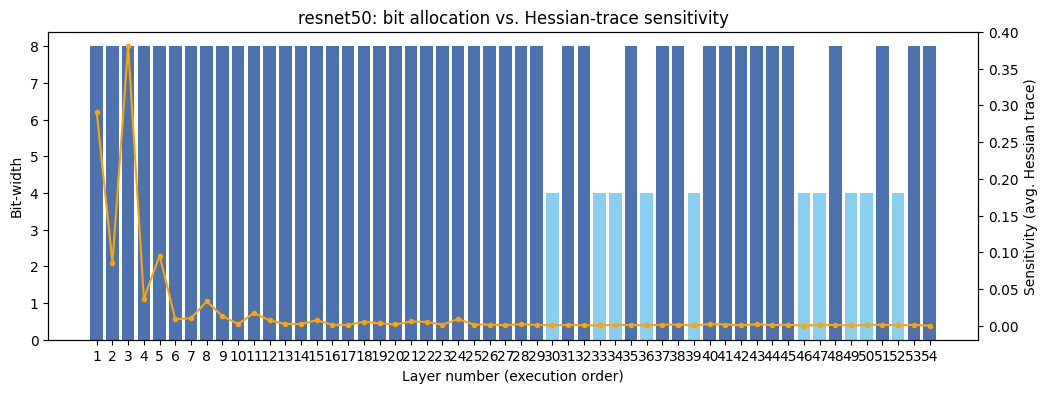

In [ ]:
# Per-layer bit allocation vs. a sensitivity score (compare to the paper's Figure I.1)
def plot_bit_assignment(bit_config, scores, title, score_label):
    bits = [bit_config[n] for n in layer_names]
    xs = range(len(layer_names))
    fig, ax1 = plt.subplots(figsize=(max(12, len(layer_names) * 0.2), 4))
    ax1.bar(xs, bits, color=["#4C72B0" if b == 8 else "#89CFF0" for b in bits])
    ax1.set_ylabel("Bit-width")
    ax1.set_xlabel("Layer number (execution order)")
    step = max(1, len(layer_names) // 30)
    ax1.set_xticks(list(xs)[::step])
    ax1.set_xticklabels([i + 1 for i in xs][::step])
    ax2 = ax1.twinx()
    ax2.plot(xs, [scores[n] for n in layer_names], color="orange", marker="o", markersize=3)
    ax2.set_ylabel(score_label)
    plt.title(title)
    plt.show()

plot_bit_assignment(results["Mixed (Hessian trace (HAWQ-V3))"]["bit_config"], hessian_traces,
                    f"{MODEL_NAME}: bit allocation vs. Hessian-trace sensitivity",
                    "Sensitivity (avg. Hessian trace)")

Size budget sweep:   0%|          | 0/5 [00:00<?, ?it/s]

budget 13.15 MB:   0%|          | 0/79 [00:00<?, ?it/s]

budget 15.94 MB:   0%|          | 0/79 [00:00<?, ?it/s]

budget 18.74 MB:   0%|          | 0/79 [00:00<?, ?it/s]

budget 21.53 MB:   0%|          | 0/79 [00:00<?, ?it/s]

budget 24.33 MB:   0%|          | 0/79 [00:00<?, ?it/s]

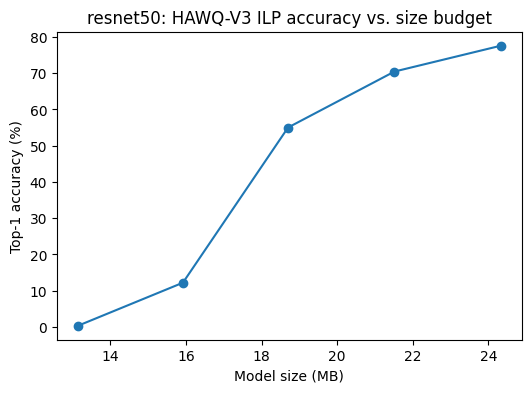

,budget_mb,size_mb,bops_g,top1
0,13.145599,13.145599,67.490546,0.32
1,15.940521,15.919037,171.689640,12.19
2,18.735443,18.700287,200.668086,55.02
3,21.530365,21.512787,224.714031,70.46
4,24.325287,24.325287,246.910288,77.59


In [ ]:
# Accuracy vs. size budget for the Hessian-trace ILP (budgets from uniform INT4 to uniform INT8)
sweep = []
for budget in tqdm(np.linspace(INT4_SIZE, INT8_SIZE, 5), desc="Size budget sweep"):
    cfg_bits = solve_ilp(omega, size_limit_mb=float(budget))
    with quantized(model, cfg_bits):
        acc = evaluate_top1(model, eval_loader, desc=f"budget {budget:.2f} MB")
    sweep.append({"budget_mb": float(budget), "size_mb": model_size_mb(cfg_bits),
                  "bops_g": model_bops_g(cfg_bits), "top1": acc})

sweep_df = pd.DataFrame(sweep)
plt.figure(figsize=(6, 4))
plt.plot(sweep_df["size_mb"], sweep_df["top1"], marker="o")
plt.xlabel("Model size (MB)")
plt.ylabel("Top-1 accuracy (%)")
plt.title(f"{MODEL_NAME}: HAWQ-V3 ILP accuracy vs. size budget")
plt.show()
sweep_df

In [ ]:
# Optional, read-only: HAWQ's published bit configurations for this model (manual comparison)
token = {"resnet18": "resnet18", "resnet50": "resnet50", "inceptionv3": "inception"}[MODEL_NAME]
path = os.path.join("HAWQ", "bit_config.py")
if not os.path.exists(path):
    print("HAWQ/bit_config.py not found (rerun the install cell to clone the repo).")
else:
    try:
        spec = importlib.util.spec_from_file_location("hawq_bit_config", path)
        hawq_cfg = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(hawq_cfg)
        found = 0
        for var_name, value in vars(hawq_cfg).items():
            if not isinstance(value, dict):
                continue
            for key, cfg in value.items():
                if token in str(key).lower() and isinstance(cfg, dict):
                    n4 = sum(1 for b in cfg.values() if b == 4)
                    print(f"{var_name}['{key}']: {len(cfg)} entries, {n4} at 4-bit")
                    found += 1
        if not found:
            print(f"No configurations mentioning '{token}' found in HAWQ/bit_config.py.")
    except Exception as e:
        print("Could not read HAWQ/bit_config.py:", e)

bit_config_dict['bit_config_resnet50_uniform8']: 121 entries, 0 at 4-bit
bit_config_dict['bit_config_resnet50_uniform4']: 121 entries, 100 at 4-bit
bit_config_dict['bit_config_resnet50_modelsize_0.75']: 121 entries, 6 at 4-bit
bit_config_dict['bit_config_resnet50_modelsize_0.5']: 121 entries, 20 at 4-bit
bit_config_dict['bit_config_resnet50_modelsize_0.25']: 121 entries, 39 at 4-bit
bit_config_dict['bit_config_resnet50_bops_0.75']: 121 entries, 18 at 4-bit
bit_config_dict['bit_config_resnet50_bops_0.5']: 121 entries, 38 at 4-bit
bit_config_dict['bit_config_resnet50_bops_0.25']: 121 entries, 70 at 4-bit
bit_config_dict['bit_config_resnet50_latency_0.75']: 121 entries, 16 at 4-bit
bit_config_dict['bit_config_resnet50_latency_0.5']: 121 entries, 40 at 4-bit
bit_config_dict['bit_config_resnet50_latency_0.25']: 121 entries, 67 at 4-bit
bit_config_dict['bit_config_resnet50b_uniform8']: 121 entries, 0 at 4-bit
bit_config_dict['bit_config_resnet50b_uniform4']: 121 entries, 100 at 4-bit


# 7. BONUS: RQNKUP data-free sensitivity metrics

Two metrics that need **no data and no backpropagation**, only the trained weights:
- **Excess kurtosis** of a layer's weights: how outlier-heavy the distribution is. Outliers stretch the quantization range and waste levels, so high kurtosis suggests higher sensitivity.
- **Spectral (effective) rank**: the fraction of singular values needed to hold 99% of the weight matrix's energy. A higher rank suggests less redundant structure to absorb quantization noise.

Both plug into the **same** Ω and the **same** ILP budget as the Hessian metrics, so any accuracy difference comes only from the sensitivity score.

In [ ]:
# Data-free metrics: excess kurtosis and spectral (effective) rank
def excess_kurtosis(weight):
    w = weight.detach().flatten().float()
    std = w.std().clamp(min=1e-8)
    return ((((w - w.mean()) / std) ** 4).mean() - 3.0).item()

def spectral_rank(weight, energy_threshold=0.99):
    w2d = weight.detach().reshape(weight.shape[0], -1).float()
    s = torch.linalg.svdvals(w2d)
    energy = torch.cumsum(s ** 2, dim=0) / (s ** 2).sum()
    target = torch.tensor([energy_threshold], device=energy.device, dtype=energy.dtype)
    rank = min(int(torch.searchsorted(energy, target)[0].item()) + 1, len(s))
    return rank / len(s)

kurtosis_scores, rank_scores = {}, {}
for n in tqdm(layer_names, desc="Data-free metrics"):
    w = layer_inventory[n]["module"].weight
    kurtosis_scores[n] = excess_kurtosis(w)
    rank_scores[n] = spectral_rank(w)

for label, scores in [("Excess kurtosis (RQNKUP)", kurtosis_scores),
                      ("Spectral rank (RQNKUP)", rank_scores)]:
    run_config(f"Mixed ({label})", solve_ilp(make_omega(scores, label), size_limit_mb=MID_SIZE_LIMIT))

results_table()

Data-free metrics:   0%|          | 0/54 [00:00<?, ?it/s]

Mixed (Excess kurtosis (RQNKUP)):   0%|          | 0/79 [00:00<?, ?it/s]

Mixed (Spectral rank (RQNKUP)):   0%|          | 0/79 [00:00<?, ?it/s]

,method,top1,size_mb,bops_g,n_int4
0,Uniform INT4,0.32,13.145599,67.490546,52
1,Uniform INT8,77.59,24.325287,246.910288,0
2,Mixed (Hessian trace (HAWQ-V3)),55.02,18.700287,200.668086,10
3,Mixed (Top eigenvalue (HAWQ-V1)),11.64,18.729584,161.824637,22
4,Mixed (Quantization error only),37.98,18.731537,204.984025,12
5,Mixed (Random),20.99,18.729584,189.569958,14
6,Mixed (Excess kurtosis (RQNKUP)),9.03,18.729584,180.321518,19
7,Mixed (Spectral rank (RQNKUP)),11.67,18.700287,209.916527,12


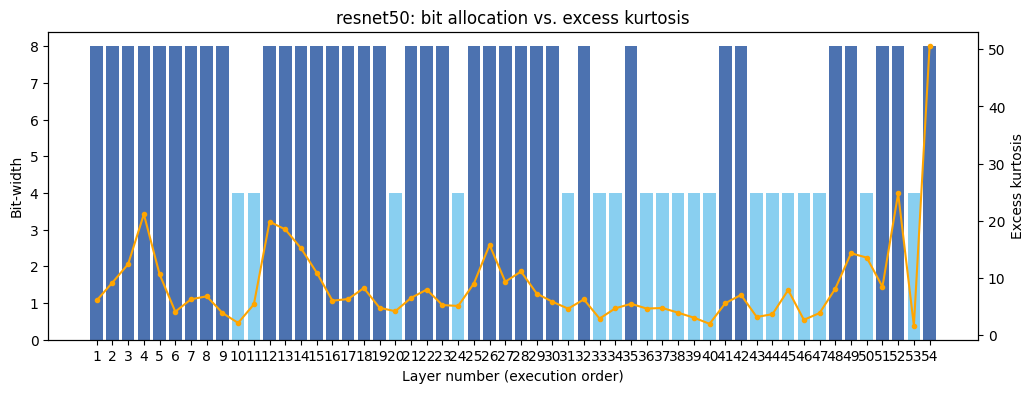

In [ ]:
# Kurtosis-chosen allocation, to compare side by side with the Hessian-trace plot in Section 6
plot_bit_assignment(results["Mixed (Excess kurtosis (RQNKUP))"]["bit_config"], kurtosis_scores,
                    f"{MODEL_NAME}: bit allocation vs. excess kurtosis", "Excess kurtosis")

Hessian trace (HAWQ-V3) @ 70%:   0%|          | 0/79 [00:00<?, ?it/s]

Top eigenvalue (HAWQ-V1) @ 70%:   0%|          | 0/79 [00:00<?, ?it/s]

Quantization error only @ 70%:   0%|          | 0/79 [00:00<?, ?it/s]

Random @ 70%:   0%|          | 0/79 [00:00<?, ?it/s]

Excess kurtosis (RQNKUP) @ 70%:   0%|          | 0/79 [00:00<?, ?it/s]

...

Top eigenvalue (HAWQ-V1) @ 95%:   0%|          | 0/79 [00:00<?, ?it/s]

Quantization error only @ 95%:   0%|          | 0/79 [00:00<?, ?it/s]

Random @ 95%:   0%|          | 0/79 [00:00<?, ?it/s]

Excess kurtosis (RQNKUP) @ 95%:   0%|          | 0/79 [00:00<?, ?it/s]

Spectral rank (RQNKUP) @ 95%:   0%|          | 0/79 [00:00<?, ?it/s]

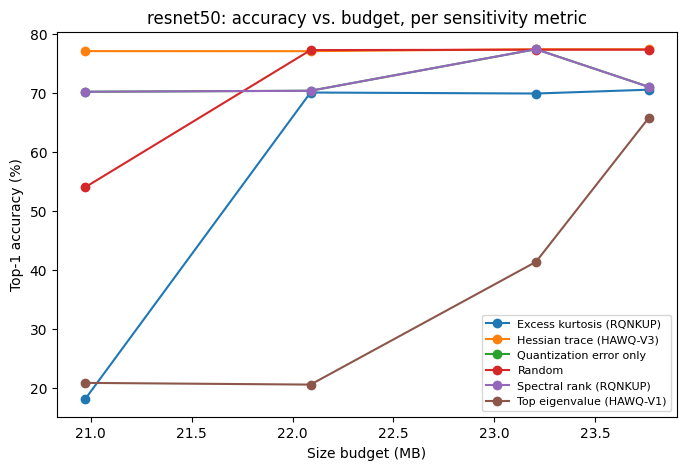

budget_frac,0.70,0.80,0.90,0.95
metric,,,,
Excess kurtosis (RQNKUP),18.09,70.08,69.91,70.56
Hessian trace (HAWQ-V3),77.10,77.09,77.42,77.42
Quantization error only,70.21,70.38,77.42,71.04
Random,54.01,77.27,77.34,77.34
Spectral rank (RQNKUP),70.21,70.38,77.42,71.04
Top eigenvalue (HAWQ-V1),20.86,20.57,41.38,65.78


In [ ]:
# Compare ALL metrics across several budgets (the midpoint budget can collapse to chance, e.g. ResNet-50)
all_metrics = dict(SENSITIVITY_METRICS)
all_metrics["Excess kurtosis (RQNKUP)"] = make_omega(kurtosis_scores, "Excess kurtosis")
all_metrics["Spectral rank (RQNKUP)"] = make_omega(rank_scores, "Spectral rank")

fractions = [0.7, 0.8, 0.9, 0.95]   # fraction of the way from uniform-INT4 size to uniform-INT8 size
budget_rows = []
for frac in fractions:
    budget = INT4_SIZE + frac * (INT8_SIZE - INT4_SIZE)
    for label, om in all_metrics.items():
        cfg_bits = solve_ilp(om, size_limit_mb=budget)
        with quantized(model, cfg_bits):
            acc = evaluate_top1(model, eval_loader, desc=f"{label} @ {frac:.0%}")
        budget_rows.append({"budget_frac": frac, "budget_mb": budget, "metric": label, "top1": acc,
                            "size_mb": model_size_mb(cfg_bits), "bops_g": model_bops_g(cfg_bits),
                            "n_int4": sum(1 for n in layer_names if effective_bits(cfg_bits, n) == 4)})

multi_budget_df = pd.DataFrame(budget_rows)
multi_budget_df.to_csv(os.path.join(RESULTS_DIR, f"{MODEL_NAME}_multi_budget.csv"), index=False)

plt.figure(figsize=(8, 5))
for label, g in multi_budget_df.groupby("metric"):
    plt.plot(g["budget_mb"], g["top1"], marker="o", label=label)
plt.xlabel("Size budget (MB)")
plt.ylabel("Top-1 accuracy (%)")
plt.title(f"{MODEL_NAME}: accuracy vs. budget, per sensitivity metric")
plt.legend(fontsize=8)
plt.show()

multi_budget_df.pivot(index="metric", columns="budget_frac", values="top1").round(2)

In [ ]:
# Is "Random" really better, or one lucky seed? Try 5 more random seeds at the 90% budget
budget90 = INT4_SIZE + 0.9 * (INT8_SIZE - INT4_SIZE)
rand_accs = []
for s in range(5):
    r = np.random.default_rng(100 + s)
    om = make_omega({n: float(r.random()) for n in layer_names}, f"Random seed {100 + s}")
    with quantized(model, solve_ilp(om, size_limit_mb=budget90)):
        rand_accs.append(evaluate_top1(model, eval_loader, desc=f"random seed {100 + s}"))
print("Random @ 90% across seeds:", [round(a, 2) for a in rand_accs],
      f"| mean {np.mean(rand_accs):.2f} ± {np.std(rand_accs):.2f}")

random seed 100:   0%|          | 0/79 [00:00<?, ?it/s]

random seed 101:   0%|          | 0/79 [00:00<?, ?it/s]

random seed 102:   0%|          | 0/79 [00:00<?, ?it/s]

random seed 103:   0%|          | 0/79 [00:00<?, ?it/s]

random seed 104:   0%|          | 0/79 [00:00<?, ?it/s]

Random @ 90% across seeds: [77.42, 77.38, 77.42, 53.22, 33.88] | mean 63.86 ± 17.68


In [ ]:
# Same bit configs, but activations kept at 8 bits: isolates weight error from activation error
for label in ["Hessian trace (HAWQ-V3)", "Random"]:
    cfg_bits = solve_ilp(all_metrics[label], size_limit_mb=budget90)
    for act_bits, tag in [(None, "W4A4 on INT4 layers"), (8, "W4 weights, A8 activations")]:
        with quantized(model, cfg_bits, act_bits=act_bits):
            acc = evaluate_top1(model, eval_loader, desc=f"{label}: {tag}")
        print(f"{label:28s} {tag:28s} -> {acc:.2f}%")

Uniform W4A8:   0%|          | 0/79 [00:00<?, ?it/s]

Uniform 4-bit weights, 8-bit activations: 57.26%


W-only Hessian trace (HAWQ-V3) @ 10%:   0%|          | 0/79 [00:00<?, ?it/s]

W-only Top eigenvalue (HAWQ-V1) @ 10%:   0%|          | 0/79 [00:00<?, ?it/s]

W-only Quantization error only @ 10%:   0%|          | 0/79 [00:00<?, ?it/s]

...

W-only Excess kurtosis (RQNKUP) @ 70%:   0%|          | 0/79 [00:00<?, ?it/s]

W-only Spectral rank (RQNKUP) @ 70%:   0%|          | 0/79 [00:00<?, ?it/s]

W-only Random (seed 200) @ 70%:   0%|          | 0/79 [00:00<?, ?it/s]

W-only Random (seed 201) @ 70%:   0%|          | 0/79 [00:00<?, ?it/s]

W-only Random (seed 202) @ 70%:   0%|          | 0/79 [00:00<?, ?it/s]

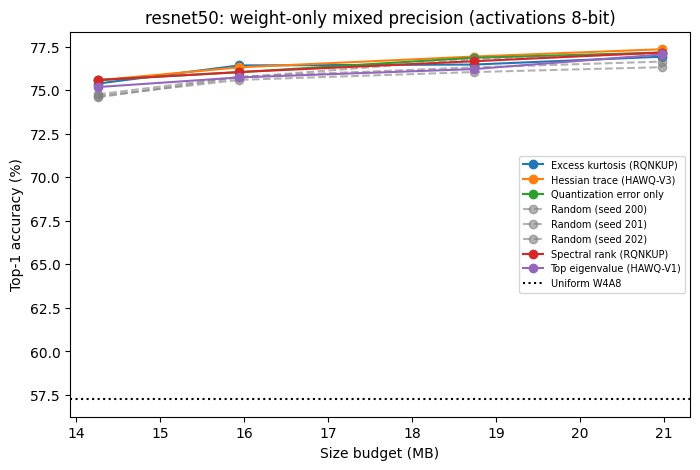

budget_frac,0.10,0.25,0.50,0.70
metric,,,,
Excess kurtosis (RQNKUP),75.38,76.42,76.47,76.92
Hessian trace (HAWQ-V3),75.57,76.31,76.93,77.35
Quantization error only,75.58,76.03,76.86,77.16
Random (seed 200),74.76,75.77,76.31,76.64
Random (seed 201),74.66,75.59,76.04,76.32
Random (seed 202),74.59,75.73,76.78,77.13
Spectral rank (RQNKUP),75.58,76.04,76.66,77.16
Top eigenvalue (HAWQ-V1),75.18,75.73,76.21,77.05


In [ ]:
# Weight-only mixed precision (ALL activations 8-bit): tests exactly what the metrics are designed to predict
with quantized(model, {n: 4 for n in layer_names}, act_bits=8):
    w4a8_uniform = evaluate_top1(model, eval_loader, desc="Uniform W4A8")
print(f"Uniform 4-bit weights, 8-bit activations: {w4a8_uniform:.2f}%")

wo_metrics = {k: v for k, v in all_metrics.items() if k != "Random"}
for s in range(3):   # several random seeds, so random is reported as a spread, not one lucky draw
    r = np.random.default_rng(200 + s)
    wo_metrics[f"Random (seed {200 + s})"] = make_omega(
        {n: float(r.random()) for n in layer_names}, f"Random seed {200 + s}")

wo_rows = []
for frac in [0.1, 0.25, 0.5, 0.7]:
    budget = INT4_SIZE + frac * (INT8_SIZE - INT4_SIZE)
    for label, om in wo_metrics.items():
        cfg_bits = solve_ilp(om, size_limit_mb=budget)
        with quantized(model, cfg_bits, act_bits=8):
            acc = evaluate_top1(model, eval_loader, desc=f"W-only {label} @ {frac:.0%}")
        wo_rows.append({"budget_frac": frac, "budget_mb": budget, "metric": label, "top1": acc,
                        "n_int4": sum(1 for n in layer_names if effective_bits(cfg_bits, n) == 4)})

wo_df = pd.DataFrame(wo_rows)
wo_df.to_csv(os.path.join(RESULTS_DIR, f"{MODEL_NAME}_weight_only_multi_budget.csv"), index=False)

plt.figure(figsize=(8, 5))
for label, g in wo_df.groupby("metric"):
    style = dict(color="gray", linestyle="--", alpha=0.6) if label.startswith("Random") else {}
    plt.plot(g["budget_mb"], g["top1"], marker="o", label=label, **style)
plt.axhline(w4a8_uniform, color="black", linestyle=":", label="Uniform W4A8")
plt.xlabel("Size budget (MB)")
plt.ylabel("Top-1 accuracy (%)")
plt.title(f"{MODEL_NAME}: weight-only mixed precision (activations 8-bit)")
plt.legend(fontsize=7)
plt.show()

wo_df.pivot(index="metric", columns="budget_frac", values="top1").round(2)

# 8. Verification & saving

1. **Integrity check:** the model must be exactly back to FP32 after all the quantized evaluations.
2. **Layer-level comparison:** which layers each metric sent to INT4, and pairwise overlaps. This is what explains *why* two metrics with the same size budget get different accuracy.
3. **Save** everything for this model to `results/<MODEL_NAME>/` in Drive, plus a combined table across all models run so far.

In [ ]:
# 1. Integrity check: the model must be fully restored to FP32
check_acc = evaluate_top1(model, eval_loader, desc="FP32 re-check")
print(f"FP32 accuracy before quantization runs: {fp32_acc:.2f}%")
print(f"FP32 accuracy after quantization runs:  {check_acc:.2f}%")
assert abs(check_acc - fp32_acc) < 0.1, "Model was NOT fully restored to FP32!"

In [ ]:
# 2a. Which layers did each metric send to INT4?
mixed = {m: r for m, r in results.items() if m.startswith("Mixed")}
int4_sets = {m: {n for n, b in r["bit_config"].items() if b == 4} for m, r in mixed.items()}
for m in mixed:
    print(f"{m:35s} top1={mixed[m]['top1']:6.2f}  {len(int4_sets[m]):3d} INT4 layers: {sorted(int4_sets[m])}")

In [ ]:
# 2b. Pairwise overlap between metrics' INT4 choices
for a, b in itertools.combinations(int4_sets, 2):
    shared = len(int4_sets[a] & int4_sets[b])
    print(f"{a:35s} vs {b:35s} -> {shared} shared / {len(int4_sets[a])} and {len(int4_sets[b])}")

Mixed (Hessian trace (HAWQ-V3))     vs Mixed (Top eigenvalue (HAWQ-V1))    -> 8 shared / 10 and 22
Mixed (Hessian trace (HAWQ-V3))     vs Mixed (Quantization error only)     -> 6 shared / 10 and 12
Mixed (Hessian trace (HAWQ-V3))     vs Mixed (Random)                      -> 6 shared / 10 and 14
Mixed (Hessian trace (HAWQ-V3))     vs Mixed (Excess kurtosis (RQNKUP))    -> 7 shared / 10 and 19
Mixed (Hessian trace (HAWQ-V3))     vs Mixed (Spectral rank (RQNKUP))      -> 5 shared / 10 and 12
Mixed (Top eigenvalue (HAWQ-V1))    vs Mixed (Quantization error only)     -> 8 shared / 22 and 12
Mixed (Top eigenvalue (HAWQ-V1))    vs Mixed (Random)                      -> 6 shared / 22 and 14
Mixed (Top eigenvalue (HAWQ-V1))    vs Mixed (Excess kurtosis (RQNKUP))    -> 15 shared / 22 and 19
Mixed (Top eigenvalue (HAWQ-V1))    vs Mixed (Spectral rank (RQNKUP))      -> 8 shared / 22 and 12
Mixed (Quantization error only)     vs Mixed (Random)                      -> 6 shared / 12 and 14
Mixed (Qu

In [ ]:
# Combined table across every model run so far (fills in as you run each model)
frames = []
for csv_path in sorted(glob.glob(os.path.join(RESULTS_ROOT, "*", "*_results.csv"))):
    df = pd.read_csv(csv_path)
    df.insert(0, "model", os.path.basename(os.path.dirname(csv_path)))
    frames.append(df)
pd.concat(frames, ignore_index=True) if frames else "No saved results yet."

In [ ]:
# 3. Save results, bit configurations, the budget sweep, and per-layer scores to Drive
results_table().to_csv(os.path.join(RESULTS_DIR, f"{MODEL_NAME}_results.csv"), index=False)
sweep_df.to_csv(os.path.join(RESULTS_DIR, f"{MODEL_NAME}_budget_sweep.csv"), index=False)
with open(os.path.join(RESULTS_DIR, f"{MODEL_NAME}_bit_configs.json"), "w") as f:
    json.dump({m: r["bit_config"] for m, r in results.items()}, f, indent=1)

per_layer = pd.DataFrame({
    "layer": layer_names,
    "weight_numel": [layer_inventory[n]["weight_numel"] for n in layer_names],
    "macs": [layer_inventory[n]["macs"] for n in layer_names],
    "hessian_trace": [hessian_traces[n] for n in layer_names],
    "top_eigenvalue": [top_eigs[n] if top_eigs is not None else np.nan for n in layer_names],
    "excess_kurtosis": [kurtosis_scores[n] for n in layer_names],
    "spectral_rank": [rank_scores[n] for n in layer_names],
    "quant_error_int4": [quant_error[n][4] for n in layer_names],
    "quant_error_int8": [quant_error[n][8] for n in layer_names],
})
per_layer.to_csv(os.path.join(RESULTS_DIR, f"{MODEL_NAME}_per_layer.csv"), index=False)
print("Saved to", RESULTS_DIR, ":", sorted(os.listdir(RESULTS_DIR)))

Saved to /content/drive/MyDrive/rqnkup/hawqv3/results/resnet50 : ['hessian_traces_iters20_n512_seed0.json', 'resnet50_bit_configs.json', 'resnet50_budget_sweep.csv', 'resnet50_multi_budget.csv', 'resnet50_per_layer.csv', 'resnet50_results.csv', 'resnet50_weight_only_multi_budget.csv', 'top_eigs_iters8_n128_seed0.json']


### Findings for this model

#### ResNet-18
- FP32 72.62% (paper 71.47%); INT8 72.52%.
- W4A4: uniform INT4 collapses (1.59%), but unlike ResNet-50, mixed precision stays usable (69.08% at the midpoint budget). At the midpoint, Hessian trace = kurtosis (69.08%) > quantization error only = spectral rank (65.11%) > top eigenvalue (63.93%) > random (59.04%); the Hessian/quantization-error gap comes from a single differing layer.
- Weight-only (W4/8, A8): mixed precision recovers about 54 points over uniform 4-bit weights (≈16% → 69.83%) with about 0.5 MB extra. Hessian trace = kurtosis at every budget; quantization error only and spectral rank slightly lower; random varies widely with seed.
- Caveat: with first/last layers fixed at 8-bit, only a few stage3/stage4 layers are worth quantizing, so many metrics land on identical configurations, and the Hessian trace's choice shifted between runs.
- For RQNKUP: kurtosis matches the Hessian trace at every budget with zero data and zero backprop, though with so few possible configurations this is weaker evidence than ResNet-50.

#### ResNet-50
- FP32 77.77% (paper 77.72%); INT8 77.35%.
- W4A4: uniform INT4 and all midpoint-budget configurations collapse to chance; the drop comes from 4-bit activations, which Ω doesn't model (same configuration with 8-bit activations: 77.19%).
- Weight-only (W4/8, A8): mixed precision recovers about 18 points over uniform 4-bit weights with about 1 MB extra. Hessian trace ≈ quantization error only ≈ kurtosis, all within noise; top eigenvalue slightly lower; random-weighted slightly lower still.
- For RQNKUP: kurtosis matches the Hessian trace with zero data and zero backprop.

#### Inception-V3
- FP32 79.96% (paper 78.88%); INT8 79.63%.
- W4A4: uniform INT4 collapses (1.19%), but unlike ResNet-50, mixed precision works well. At the midpoint budget (17.51 MB): Hessian trace 77.05% ≈ quantization error only 76.65% ≈ spectral rank 76.58% > kurtosis 75.89% > top eigenvalue 75.29% ≫ random 48.65%. Random trailing every real metric by ~27 points is the clearest evidence across all three models that the sensitivity score matters.
- Unlike the ResNets, the metrics choose substantially different layers. Kurtosis is best at the 70% budget (79.09% vs. 78.56% for the Hessian trace), and by 90% every real metric is within 0.1 points of INT8.
Weight-only (W4/8, A8): mixed precision recovers about 14 points over uniform 4-bit weights (≈64% → 78.02% with the Hessian trace) for about 0.8 MB extra. At this tightest budget, kurtosis is the weakest real metric (75.22%, below two of three random seeds), catching up by the 50–70% budgets.
- Caveat: a block of late layers has near-zero kurtosis, so Ω = score × perturbation makes them look almost free to quantize. This likely explains kurtosis's weight-only weakness, and possibly (unverified) its W4A4 strength. Spectral rank ≈ quantization error only, as on the other models. Gaps under ~1 point are within noise.
- For RQNKUP: kurtosis is competitive with the Hessian trace under W4A4 but weaker at tight weight-only budgets. A kurtosis variant that can't reach zero (raw kurtosis, or a floor) is the obvious next experiment.